# Exploratory Data Analysis and Statistical Analysis

## USD/LKR Exchange Rate Forecasting Under Economic Regime Changes

This notebook performs exploratory data analysis and statistical analysis of the official Central Bank of Sri Lanka (CBSL) USD/LKR exchange-rate series.

The main objectives of this analysis are to:

1. Examine the historical movement of the USD/LKR exchange rate.
2. Calculate daily logarithmic returns.
3. Examine the volatility of the exchange rate using a 20-day rolling volatility measure.
4. Investigate the exchange-rate behaviour during the 2022 Sri Lankan economic crisis.
5. Examine the distribution of daily returns.
6. Test the stationarity of the exchange-rate level and return series using the Augmented Dickey-Fuller (ADF) test.
7. Examine autocorrelation and partial autocorrelation using ACF and PACF plots.

The analysis is exploratory and does not assume the outcome of the statistical tests or model performance beforehand.

## 1. Import Required Libraries

The following Python libraries are used for data manipulation, visualization, and statistical analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

## 2. Load the Processed USD/LKR Dataset

The cleaned dataset generated during the data collection and cleaning stage is loaded from the `data/processed` directory.

The processed dataset contains the USD/LKR exchange rate with the date as the index and `USD_LKR` as the target variable.

In [2]:
df = pd.read_csv(
    "../data/processed/master_dataset.csv",
    parse_dates=["date"],
    index_col="date"
)

df.head()

,USD_LKR
date,
2010-05-07,113.6975
2010-05-11,113.6292
2010-05-12,113.6854
2010-05-13,113.7009
2010-05-14,113.6573


## 3. Basic Dataset Inspection

Before performing the exploratory analysis, the structure, data types, dimensions, missing values, and date range of the processed dataset are examined.

In [3]:
df.shape

(3499, 1)

In [4]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 3499 entries, 2010-05-07 to 2026-09-25
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   USD_LKR  3499 non-null   float64
dtypes: float64(1)
memory usage: 54.7 KB


In [5]:
df.isna().sum()

USD_LKR    0
dtype: int64

In [6]:
df.index.min()

Timestamp('2010-05-07 00:00:00')

In [7]:
df.index.max()

Timestamp('2026-09-25 00:00:00')

In [8]:
df.describe()

,USD_LKR
count,3499.000000
mean,206.526733
std,80.919184
min,109.459700
25%,141.541700
50%,179.672200
75%,299.827500
max,364.760000


## 4. Time Index Inspection

The exchange-rate observations are arranged chronologically. Since this is a financial time-series dataset, maintaining the correct temporal order is important for subsequent analysis and forecasting.

The dataset contains observations corresponding to published business-day exchange rates. Artificial weekend observations are not created.

In [9]:
df = df.sort_index()

df.head()

,USD_LKR
date,
2010-05-07,113.6975
2010-05-11,113.6292
2010-05-12,113.6854
2010-05-13,113.7009
2010-05-14,113.6573


## 5. Historical USD/LKR Exchange Rate

The historical movement of the USD/LKR exchange rate is visualized to identify major trends, periods of rapid appreciation or depreciation, and possible structural changes in the exchange-rate series.

Particular attention is given to the period surrounding the 2022 Sri Lankan economic crisis.

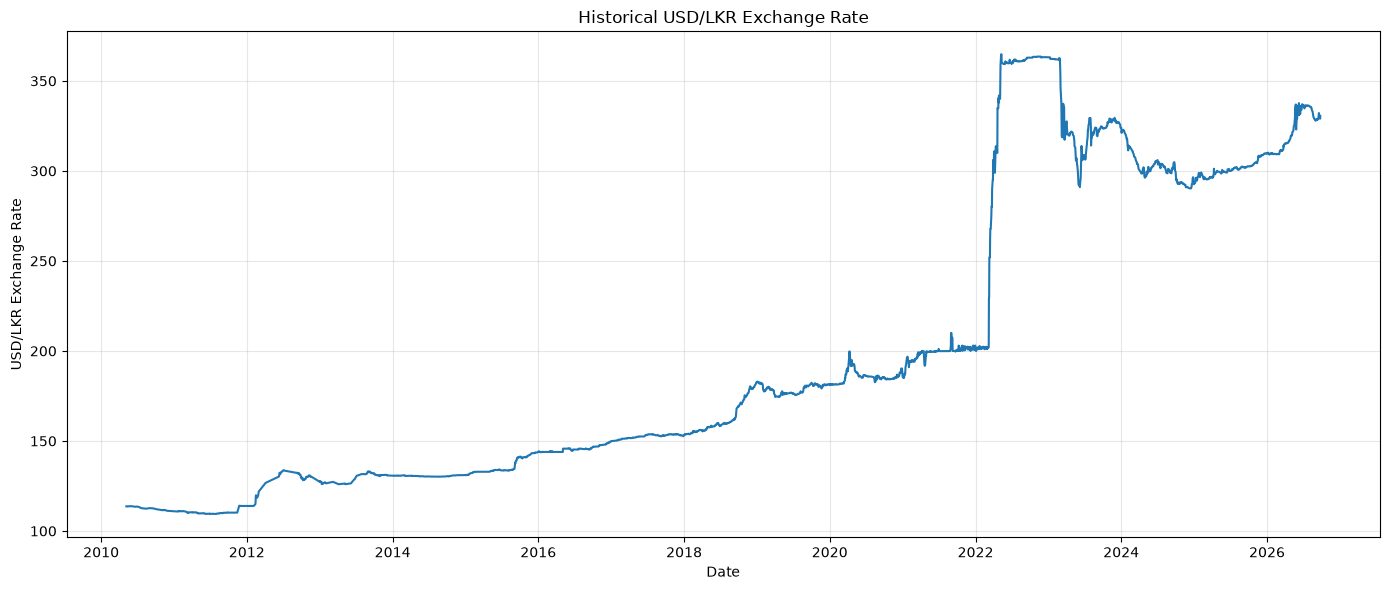

In [10]:
plt.figure(figsize=(14, 6))

plt.plot(df.index, df["USD_LKR"])

plt.title("Historical USD/LKR Exchange Rate")
plt.xlabel("Date")
plt.ylabel("USD/LKR Exchange Rate")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. USD/LKR Exchange Rate During the 2022 Crisis

The year 2022 is treated as the crisis regime in this study.

The crisis period is defined as:

**January 2022 – December 2022**

The purpose of this analysis is to examine whether the exchange rate displayed noticeably different behaviour during the crisis compared with surrounding periods.

In [11]:
crisis_2022 = df.loc["2022-01-01":"2022-12-31"]

crisis_2022.head()

,USD_LKR
date,
2022-01-03,200.4338
2022-01-04,200.0000
2022-01-05,201.7081
2022-01-06,201.0480
2022-01-07,201.3347


In [12]:
crisis_2022.shape

(240, 1)

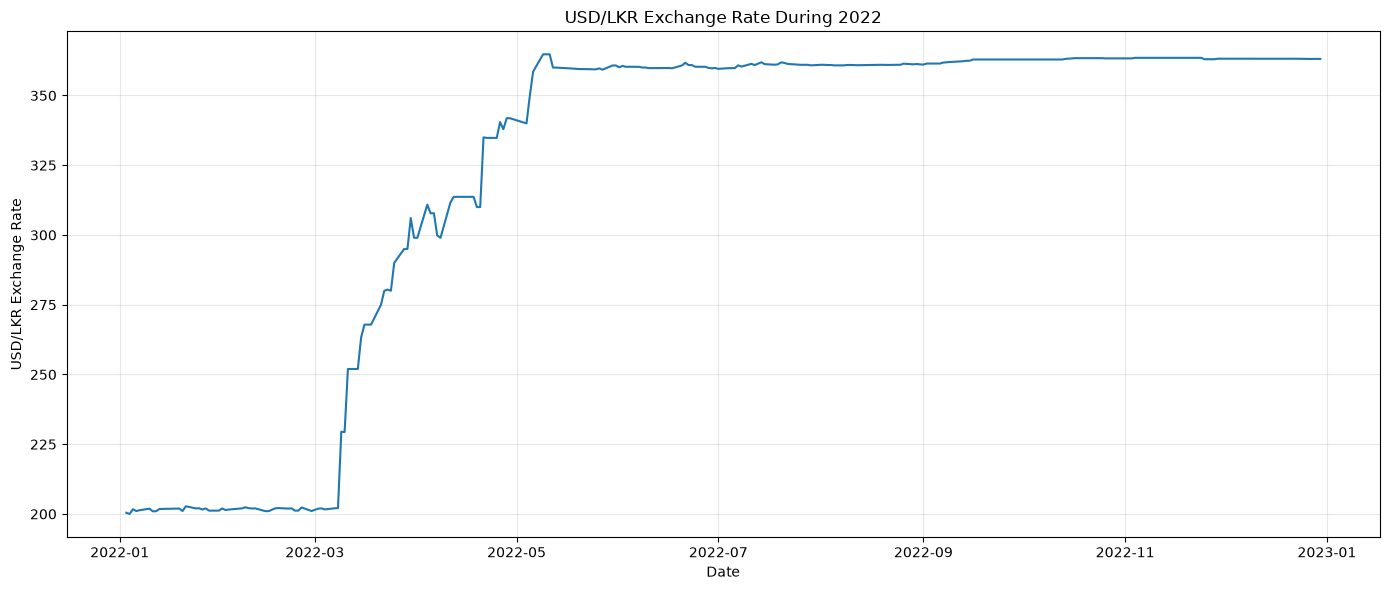

In [13]:
plt.figure(figsize=(14, 6))

plt.plot(crisis_2022.index, crisis_2022["USD_LKR"])

plt.title("USD/LKR Exchange Rate During 2022")
plt.xlabel("Date")
plt.ylabel("USD/LKR Exchange Rate")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Daily Log Returns

The daily logarithmic return is calculated to examine changes in the USD/LKR exchange rate rather than its absolute level.

The logarithmic return is calculated as:

$$
r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)
$$

where:

- $P_t$ is the USD/LKR exchange rate on day $t$
- $P_{t-1}$ is the exchange rate on the previous observation
- $r_t$ is the daily logarithmic return

Returns are useful for analysing changes in the exchange rate, stationarity, autocorrelation, and volatility.

In [14]:
df["log_return"] = np.log(
    df["USD_LKR"] / df["USD_LKR"].shift(1)
)

In [15]:
df[["USD_LKR", "log_return"]].head()

,USD_LKR,log_return
date,,
2010-05-07,113.6975,NaN
2010-05-11,113.6292,-0.000601
2010-05-12,113.6854,0.000494
2010-05-13,113.7009,0.000136
2010-05-14,113.6573,-0.000384


In [16]:
df["log_return"].isna().sum()

np.int64(1)

## 8. Daily Log Return Behaviour

The daily logarithmic returns are plotted to examine short-term fluctuations in the exchange rate.

Large positive or negative movements may indicate periods of increased market instability or volatility.

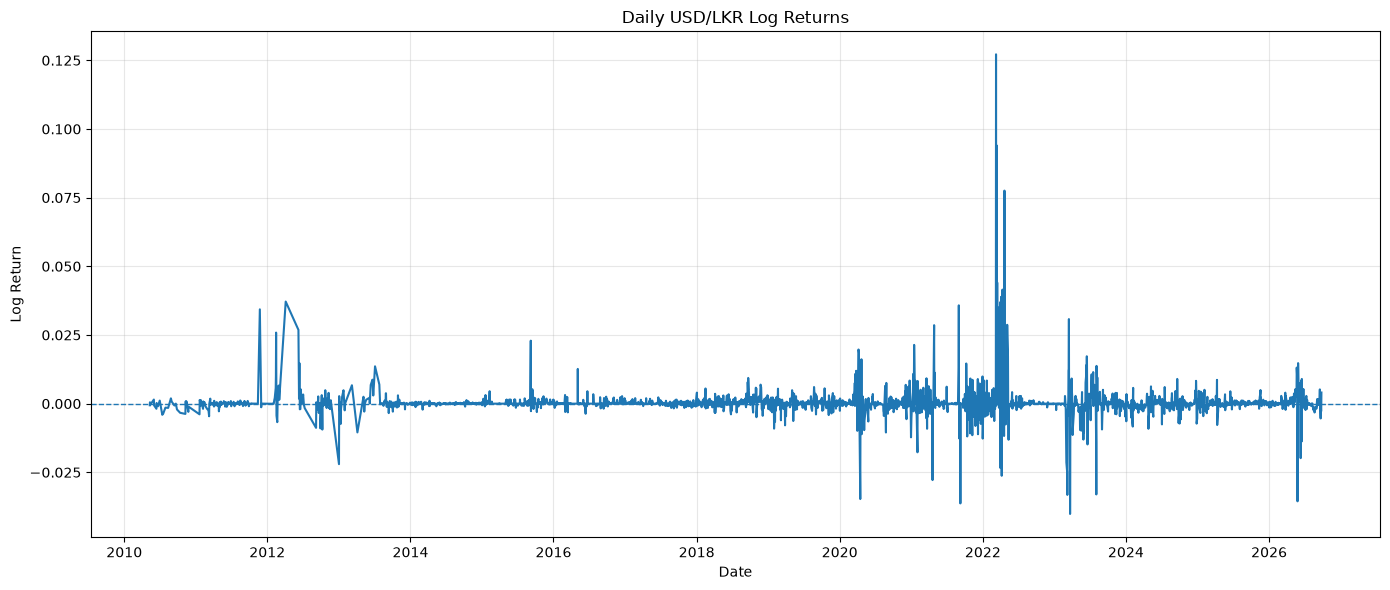

In [17]:
plt.figure(figsize=(14, 6))

plt.plot(df.index, df["log_return"])

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1
)

plt.title("Daily USD/LKR Log Returns")
plt.xlabel("Date")
plt.ylabel("Log Return")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. 20-Day Rolling Volatility

A 20-observation rolling standard deviation of daily log returns is used as a measure of short-term volatility.

The rolling volatility helps identify periods where exchange-rate fluctuations became larger or smaller over time.

A 20-day window is used to provide a relatively short-term measure of changing volatility.

In [18]:
df["rolling_volatility_20"] = (
    df["log_return"]
    .rolling(window=20)
    .std()
)

In [19]:
df[["log_return", "rolling_volatility_20"]].tail()

,log_return,rolling_volatility_20
date,,
2026-09-21,-0.005388,0.002268
2026-09-22,0.001402,0.002171
2026-09-23,-0.002802,0.002209
2026-09-24,-0.002643,0.002271
2026-09-25,0.004054,0.002423


## 10. 20-Day Rolling Volatility Over Time

The 20-day rolling volatility is plotted to identify periods of elevated and reduced exchange-rate variability.

The 2022 crisis period is examined as a particular period of interest because the research question investigates whether forecasting behaviour changes under different volatility regimes.

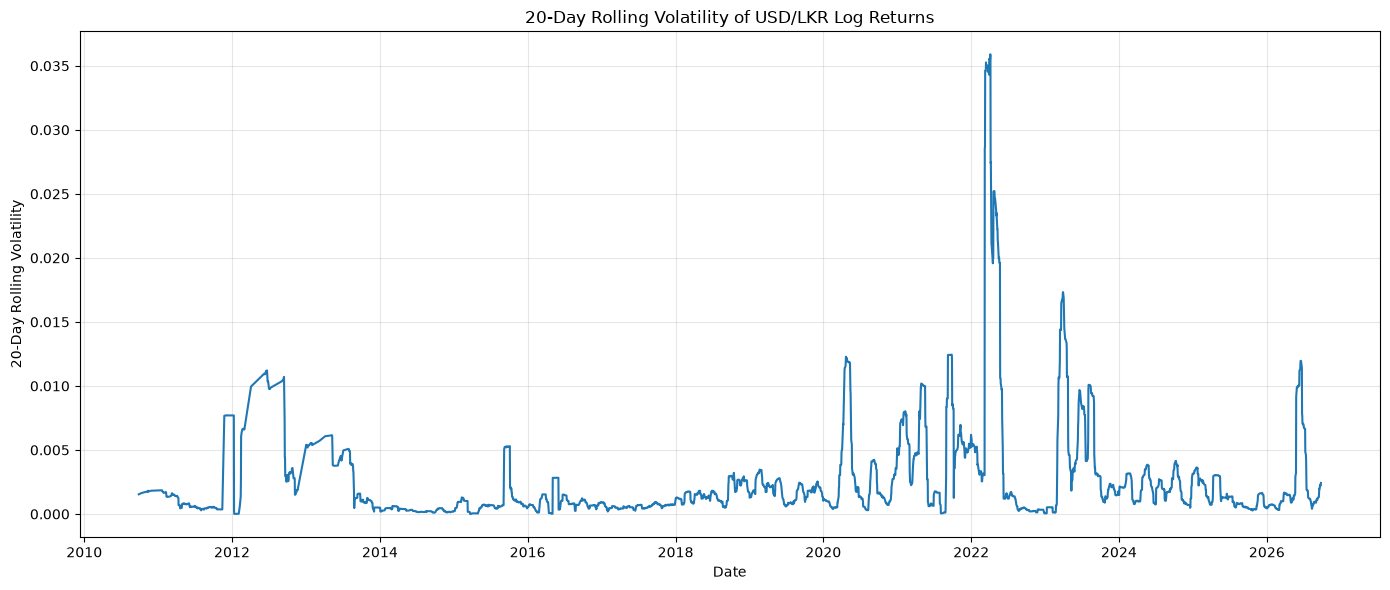

In [20]:
plt.figure(figsize=(14, 6))

plt.plot(
    df.index,
    df["rolling_volatility_20"]
)

plt.title("20-Day Rolling Volatility of USD/LKR Log Returns")
plt.xlabel("Date")
plt.ylabel("20-Day Rolling Volatility")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Rolling Volatility During the 2022 Crisis

The rolling volatility during 2022 is isolated to examine whether the crisis period contains noticeable changes in short-term exchange-rate variability.

In [21]:
crisis_volatility = df.loc[
    "2022-01-01":"2022-12-31",
    "rolling_volatility_20"
]

crisis_volatility.describe()

count    240.000000
mean       0.006927
std        0.010817
min        0.000053
25%        0.000349
50%        0.001390
75%        0.005363
max        0.035897
Name: rolling_volatility_20, dtype: float64

## 12. Distribution of Daily Log Returns

The distribution of daily log returns is examined to understand the statistical behaviour of exchange-rate changes.

The analysis focuses on:

- central tendency
- dispersion
- asymmetry
- extreme observations

The distribution is visualized using a histogram with a kernel density estimate.

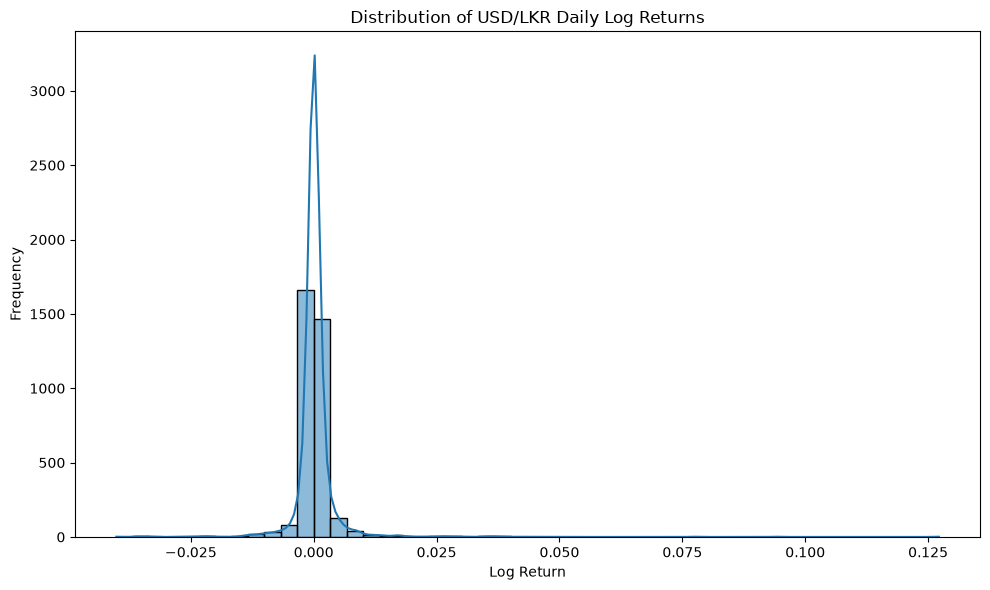

In [22]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["log_return"].dropna(),
    bins=50,
    kde=True
)

plt.title("Distribution of USD/LKR Daily Log Returns")
plt.xlabel("Log Return")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

## 13. Boxplot of Daily Log Returns

A boxplot is used to identify the spread of daily returns and potential extreme observations.

These observations are not automatically removed because extreme movements may represent genuine economic events rather than data errors.

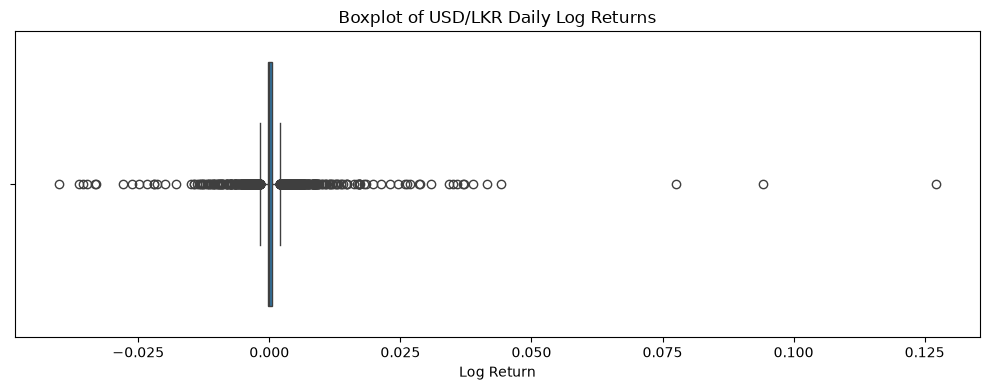

In [23]:
plt.figure(figsize=(10, 4))

sns.boxplot(
    x=df["log_return"].dropna()
)

plt.title("Boxplot of USD/LKR Daily Log Returns")
plt.xlabel("Log Return")

plt.tight_layout()
plt.show()

## 14. Summary Statistics of Daily Log Returns

Descriptive statistics are calculated for the daily log returns to quantify their central tendency and variability.

In [24]:
df["log_return"].describe()

count    3498.000000
mean        0.000305
std         0.004890
min        -0.040162
25%        -0.000332
50%         0.000000
75%         0.000604
max         0.127185
Name: log_return, dtype: float64

## 15. Augmented Dickey-Fuller Stationarity Test

The Augmented Dickey-Fuller (ADF) test is used to examine whether a time series is stationary.

The ADF test is applied separately to:

1. The USD/LKR exchange-rate level.
2. The daily log-return series.

The null hypothesis of the ADF test is that the series contains a unit root and is therefore non-stationary.

The alternative hypothesis is that the series is stationary.

The final interpretation is based on the actual test statistic and p-value obtained from the dataset rather than assuming the result beforehand.

In [25]:
def adf_test(series, name):
    result = adfuller(series.dropna())

    print(f"ADF Test: {name}")
    print("-" * 50)
    print(f"ADF Statistic: {result[0]:.6f}")
    print(f"p-value: {result[1]:.6f}")
    print(f"Number of Lags Used: {result[2]}")
    print(f"Number of Observations Used: {result[3]}")
    
    print("\nCritical Values:")
    for key, value in result[4].items():
        print(f"{key}: {value:.6f}")

In [26]:
adf_test(
    df["USD_LKR"],
    "USD/LKR Exchange Rate Level"
)

ADF Test: USD/LKR Exchange Rate Level
--------------------------------------------------
ADF Statistic: -0.992196
p-value: 0.756100
Number of Lags Used: 29
Number of Observations Used: 3469

Critical Values:
1%: -3.432236
5%: -2.862374
10%: -2.567214


C:\Users\hasnd\AppData\Local\Temp\ipykernel_18356\12455425.py:2: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(series.dropna())


In [27]:
adf_test(
    df["log_return"],
    "USD/LKR Log Returns"
)

ADF Test: USD/LKR Log Returns
--------------------------------------------------
ADF Statistic: -8.442357
p-value: 0.000000
Number of Lags Used: 28
Number of Observations Used: 3469

Critical Values:
1%: -3.432236
5%: -2.862374
10%: -2.567214


C:\Users\hasnd\AppData\Local\Temp\ipykernel_18356\12455425.py:2: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(series.dropna())


In [28]:
def interpret_adf(series, name, alpha=0.05):
    result = adfuller(series.dropna())
    p_value = result[1]

    print(f"{name}")
    print(f"ADF Statistic: {result[0]:.6f}")
    print(f"p-value: {p_value:.6f}")

    if p_value < alpha:
        print(
            f"Conclusion: Reject the null hypothesis at the "
            f"{alpha:.0%} significance level."
        )
        print("The series provides evidence of stationarity.")
    else:
        print(
            f"Conclusion: Fail to reject the null hypothesis at the "
            f"{alpha:.0%} significance level."
        )
        print("The series does not provide sufficient evidence of stationarity.")

In [29]:
interpret_adf(
    df["USD_LKR"],
    "USD/LKR Exchange Rate Level"
)

USD/LKR Exchange Rate Level
ADF Statistic: -0.992196
p-value: 0.756100
Conclusion: Fail to reject the null hypothesis at the 5% significance level.
The series does not provide sufficient evidence of stationarity.


C:\Users\hasnd\AppData\Local\Temp\ipykernel_18356\1265985884.py:2: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(series.dropna())


In [30]:
interpret_adf(
    df["log_return"],
    "USD/LKR Log Returns"
)

USD/LKR Log Returns
ADF Statistic: -8.442357
p-value: 0.000000
Conclusion: Reject the null hypothesis at the 5% significance level.
The series provides evidence of stationarity.


C:\Users\hasnd\AppData\Local\Temp\ipykernel_18356\1265985884.py:2: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(series.dropna())


## 16. Autocorrelation Function (ACF)

The Autocorrelation Function (ACF) is used to examine the correlation between the current daily log return and previous observations of the return series.

The ACF is calculated for the daily log-return series because the subsequent time-series modelling stage will investigate the dynamics of exchange-rate changes.

The ACF can provide information about the presence and strength of serial dependence across different lags.

<Figure size 1200x600 with 0 Axes>

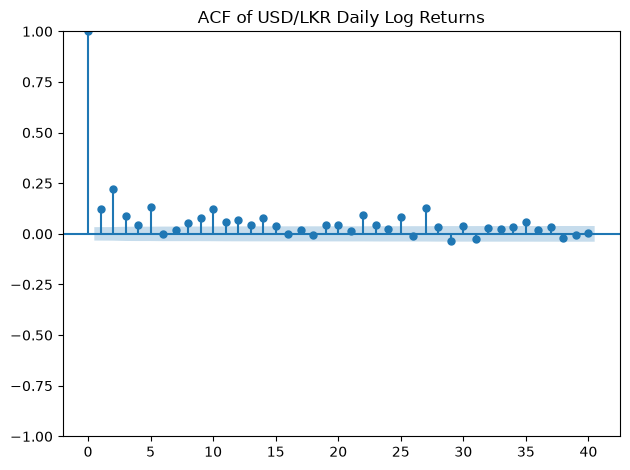

In [31]:
plt.figure(figsize=(12, 6))

plot_acf(
    df["log_return"].dropna(),
    lags=40
)

plt.title("ACF of USD/LKR Daily Log Returns")
plt.tight_layout()
plt.show()

## 17. Partial Autocorrelation Function (PACF)

The Partial Autocorrelation Function (PACF) measures the relationship between the current observation and a particular lag after accounting for the effects of intermediate lags.

PACF is examined together with ACF to understand the temporal dependence structure of the return series and to support subsequent time-series model specification.

<Figure size 1200x600 with 0 Axes>

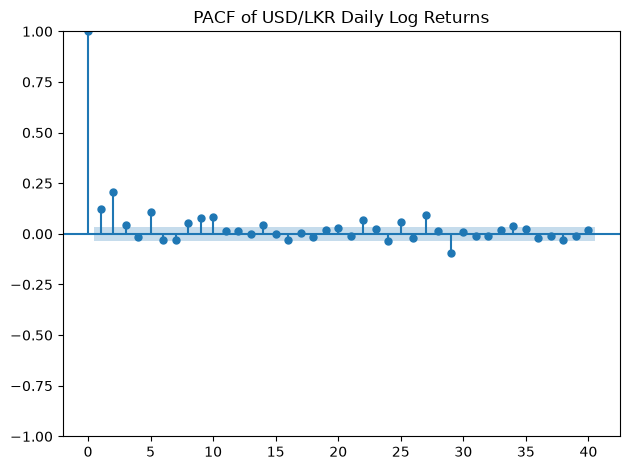

In [32]:
plt.figure(figsize=(12, 6))

plot_pacf(
    df["log_return"].dropna(),
    lags=40,
    method="ywm"
)

plt.title("PACF of USD/LKR Daily Log Returns")
plt.tight_layout()
plt.show()

## 18. Crisis and Stabilization Periods

To support the later regime-based modelling analysis, the dataset is divided into two descriptive periods:

- **Crisis:** January 2022 – December 2022
- **Stabilization:** January 2023 – December 2024

This section does not determine model performance. Instead, it examines whether the underlying exchange-rate and volatility characteristics differ between the two periods.

In [33]:
crisis = df.loc["2022-01-01":"2022-12-31"].copy()

stabilization = df.loc["2023-01-01":"2024-12-31"].copy()

In [34]:
comparison = pd.DataFrame({
    "Crisis_2022": crisis["log_return"].describe(),
    "Stabilization_2023_2024": stabilization["log_return"].describe()
})

comparison

,Crisis_2022,Stabilization_2023_2024
count,240.000000,484.000000
mean,0.002476,-0.000446
std,0.013481,0.005111
min,-0.026258,-0.040162
25%,-0.000153,-0.001454
50%,0.000000,-0.000044
75%,0.000352,0.000794
max,0.127185,0.030787


In [35]:
volatility_comparison = pd.DataFrame({
    "Crisis_2022": crisis["rolling_volatility_20"].describe(),
    "Stabilization_2023_2024": stabilization["rolling_volatility_20"].describe()
})

volatility_comparison

,Crisis_2022,Stabilization_2023_2024
count,240.000000,484.000000
mean,0.006927,0.003467
std,0.010817,0.003560
min,0.000053,0.000053
25%,0.000349,0.001198
50%,0.001390,0.002167
75%,0.005363,0.003670
max,0.035897,0.017321


## 19. Crisis vs Stabilization: Exchange-Rate Behaviour

The USD/LKR exchange rate is plotted separately for the crisis and stabilization periods to visually examine differences in the level and movement of the exchange rate.

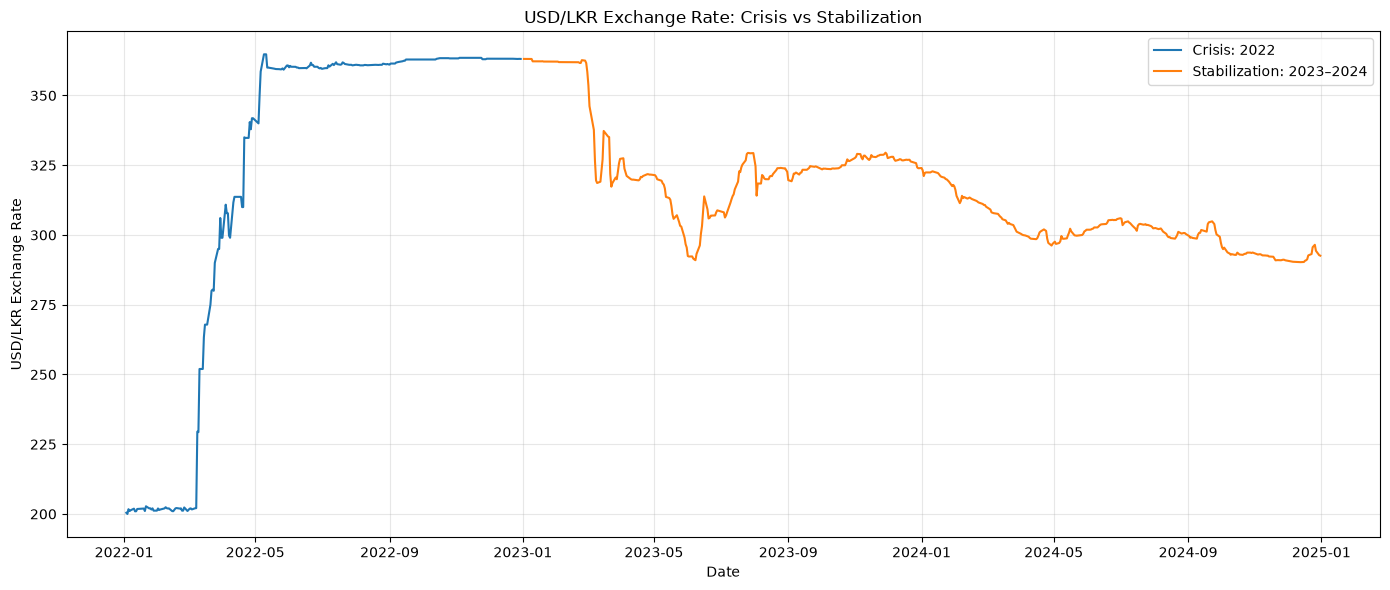

In [36]:
plt.figure(figsize=(14, 6))

plt.plot(
    crisis.index,
    crisis["USD_LKR"],
    label="Crisis: 2022"
)

plt.plot(
    stabilization.index,
    stabilization["USD_LKR"],
    label="Stabilization: 2023–2024"
)

plt.title("USD/LKR Exchange Rate: Crisis vs Stabilization")
plt.xlabel("Date")
plt.ylabel("USD/LKR Exchange Rate")

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 20. Crisis vs Stabilization: Rolling Volatility

The 20-day rolling volatility is compared between the crisis and stabilization periods.

The purpose is to examine whether the degree of short-term exchange-rate variability appears different between the two periods.

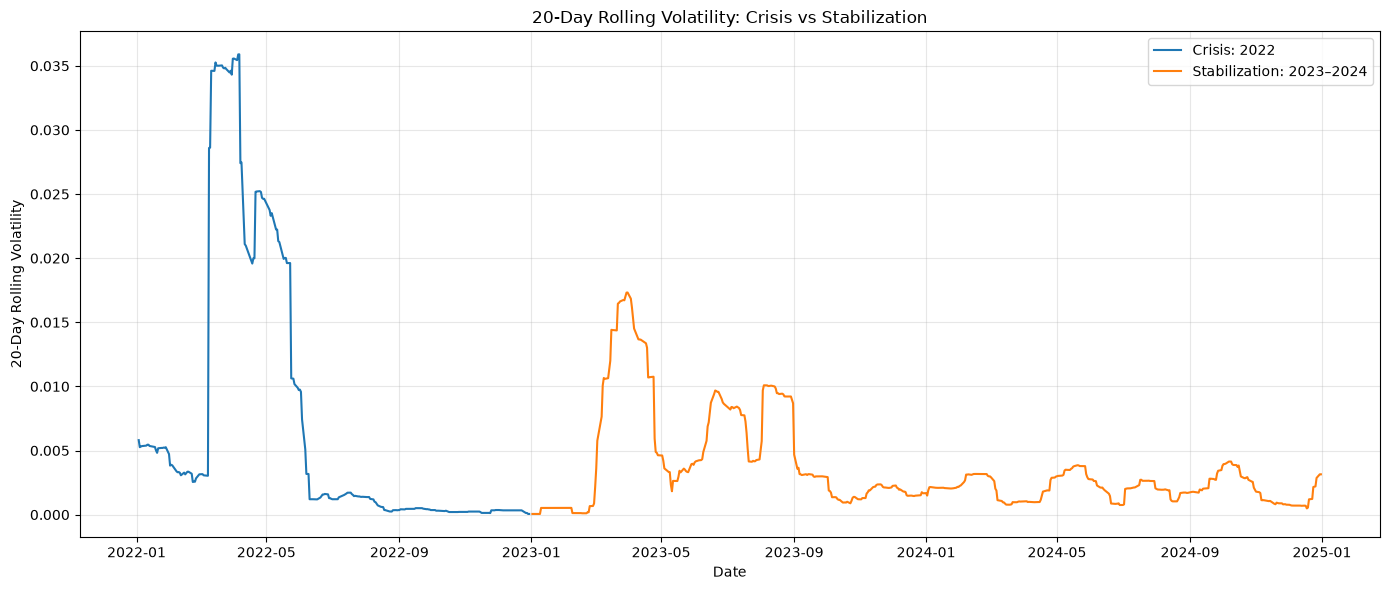

In [37]:
plt.figure(figsize=(14, 6))

plt.plot(
    crisis.index,
    crisis["rolling_volatility_20"],
    label="Crisis: 2022"
)

plt.plot(
    stabilization.index,
    stabilization["rolling_volatility_20"],
    label="Stabilization: 2023–2024"
)

plt.title("20-Day Rolling Volatility: Crisis vs Stabilization")
plt.xlabel("Date")
plt.ylabel("20-Day Rolling Volatility")

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 21. Return Distribution: Crisis vs Stabilization

The distribution of daily log returns is compared between the 2022 crisis and the 2023–2024 stabilization period.

This provides descriptive evidence about whether the magnitude and dispersion of daily exchange-rate movements differ between the two regimes.

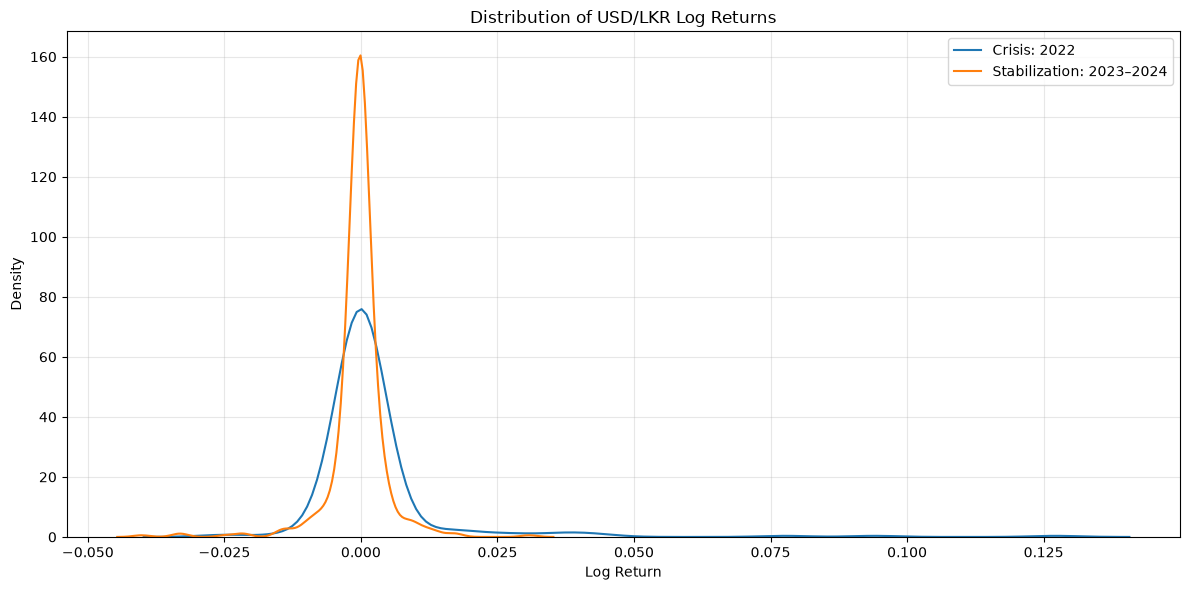

In [38]:
plt.figure(figsize=(12, 6))

sns.kdeplot(
    crisis["log_return"].dropna(),
    label="Crisis: 2022"
)

sns.kdeplot(
    stabilization["log_return"].dropna(),
    label="Stabilization: 2023–2024"
)

plt.title("Distribution of USD/LKR Log Returns")
plt.xlabel("Log Return")
plt.ylabel("Density")

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 22. Summary of Crisis and Stabilization Characteristics

The following table summarizes selected descriptive characteristics of the USD/LKR exchange-rate series across the two periods.

The values are descriptive statistics and should not be interpreted as evidence of causality.

In [39]:
summary_table = pd.DataFrame({
    "Crisis_2022": {
        "Mean USD/LKR": crisis["USD_LKR"].mean(),
        "Std USD/LKR": crisis["USD_LKR"].std(),
        "Mean Log Return": crisis["log_return"].mean(),
        "Std Log Return": crisis["log_return"].std(),
        "Mean Rolling Volatility": crisis["rolling_volatility_20"].mean()
    },
    
    "Stabilization_2023_2024": {
        "Mean USD/LKR": stabilization["USD_LKR"].mean(),
        "Std USD/LKR": stabilization["USD_LKR"].std(),
        "Mean Log Return": stabilization["log_return"].mean(),
        "Std Log Return": stabilization["log_return"].std(),
        "Mean Rolling Volatility": stabilization["rolling_volatility_20"].mean()
    }
})

summary_table

,Crisis_2022,Stabilization_2023_2024
Mean USD/LKR,324.550599,314.825552
Std USD/LKR,61.949290,18.963488
Mean Log Return,0.002476,-0.000446
Std Log Return,0.013481,0.005111
Mean Rolling Volatility,0.006927,0.003467


## 23. Data Quality Checks

Additional checks are performed to ensure that the dataset used for statistical analysis does not contain duplicate dates or invalid exchange-rate values.

In [40]:
df.index.duplicated().sum()

np.int64(0)

In [41]:
(df["USD_LKR"] <= 0).sum()

np.int64(0)

## 24. Final EDA Dataset

The final dataset used for exploratory and statistical analysis contains the original USD/LKR exchange-rate series together with the derived log-return and 20-day rolling-volatility variables.

In [42]:
df.head()

,USD_LKR,log_return,rolling_volatility_20
date,,,
2010-05-07,113.6975,NaN,NaN
2010-05-11,113.6292,-0.000601,NaN
2010-05-12,113.6854,0.000494,NaN
2010-05-13,113.7009,0.000136,NaN
2010-05-14,113.6573,-0.000384,NaN


In [43]:
df.tail()

,USD_LKR,log_return,rolling_volatility_20
date,,,
2026-09-21,330.3490,-0.005388,0.002268
2026-09-22,330.8125,0.001402,0.002171
2026-09-23,329.8867,-0.002802,0.002209
2026-09-24,329.0158,-0.002643,0.002271
2026-09-25,330.3522,0.004054,0.002423


In [44]:
df[[
    "USD_LKR",
    "log_return",
    "rolling_volatility_20"
]].describe()

,USD_LKR,log_return,rolling_volatility_20
count,3499.000000,3498.000000,3479.000000
mean,206.526733,0.000305,0.002469
std,80.919184,0.004890,0.003992
min,109.459700,-0.040162,0.000003
25%,141.541700,-0.000332,0.000582
50%,179.672200,0.000000,0.001189
75%,299.827500,0.000604,0.002663
max,364.760000,0.127185,0.035897


## 25. Save the EDA Dataset

The dataset containing the USD/LKR exchange rate, daily log returns, and 20-day rolling volatility is saved for use in the subsequent feature-engineering and modelling stages.

In [45]:
df.to_csv("../data/processed/usd_lkr_eda.csv")

# 26. EDA Summary

This exploratory analysis examined the historical behaviour of the official USD/LKR exchange-rate series.

The analysis included:

- historical USD/LKR exchange-rate movement,
- daily logarithmic returns,
- 20-day rolling volatility,
- the 2022 crisis period,
- return distributions,
- descriptive statistics,
- Augmented Dickey-Fuller stationarity testing,
- autocorrelation analysis using ACF,
- partial autocorrelation analysis using PACF, and
- descriptive comparison between the 2022 crisis and the 2023–2024 stabilization period.

The statistical findings from the ADF test, ACF/PACF analysis, and volatility analysis will be used to inform the subsequent feature-engineering and forecasting-model stages.

No model-performance conclusion is drawn at this stage. The later modelling stage will empirically evaluate the Naive, ARIMA, GARCH, XGBoost, and LSTM approaches using time-based evaluation.

## 27. Save the EDA Dataset

The final EDA dataset contains the original USD/LKR exchange-rate series together with the derived daily logarithmic returns and 20-day rolling volatility.

This processed dataset will be used as the input for the subsequent feature-engineering stage.